In [55]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
# import PercentFormatter
from matplotlib.ticker import PercentFormatter

df = pd.read_csv('./data/logistics_CLEANED_data.csv')

# Data cleanup
df['Shipment_Date'] = pd.to_datetime(df['Shipment_Date'])
df['Delivery_Date'] = pd.to_datetime(df['Delivery_Date'])

# 2.0 `Exploratory Data Analysis`


## 2.1 Delivery Performance


### 2.1.1 how many shipments were Delivered, Delayed, Cancelled, and In Transit?


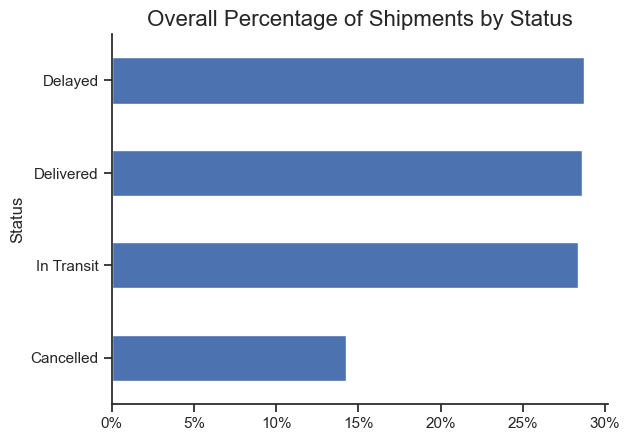

In [89]:
""" Checking no. / percentage of shipments per status"""
status_plot = df['Status'].value_counts().to_frame()
sns.set_theme(style='ticks')
status_plot.reset_index(inplace=True)
status_plot['percent'] = (status_plot['count'] / 144036) * 100
status_plot[::-1].plot(kind='barh', x='Status', y='percent', legend=False)
plt.title('Overall Percentage of Shipments by Status', fontsize=16)
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f'{int(x)}%'
    )
)
sns.despine()

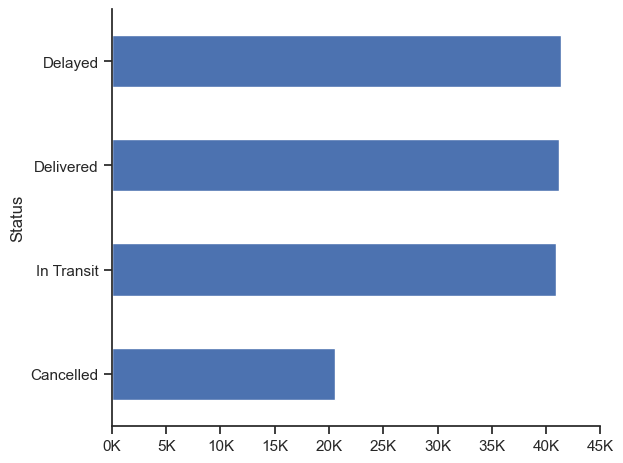

In [85]:
status_plot[::-1].plot(kind='barh', x='Status', y='count', legend=False)
plt.xlim(0, 45000)
sns.despine()
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f'{int(x/1000)}K'
    )
)
plt.tight_layout()

### 2.1.2 What percentage of all shipments were late?


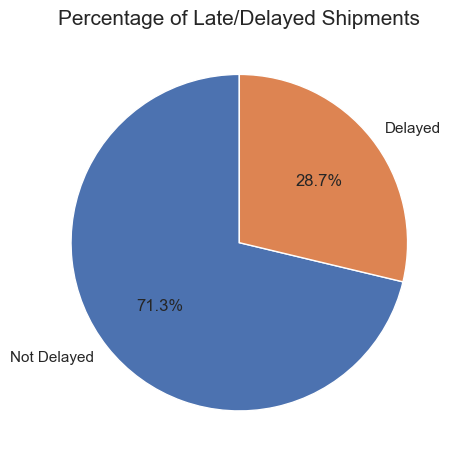

In [23]:
""" Calculating the Percentage of Shipments that were Late(Delayed)"""

delay = df['Is_Late'].value_counts()
# delay.plot(kind='pie', startangle=90, autopct='%1.1f%%')
plt.pie(delay, startangle=90, autopct='%1.1f%%', labels=['Not Delayed', 'Delayed'])
plt.title('Percentage of Late/Delayed Shipments', fontsize=15)
plt.ylabel('')
plt.tight_layout()


28.7% of Shipments were late


### 2.1.3 Which origin city has the highest late shipment rate


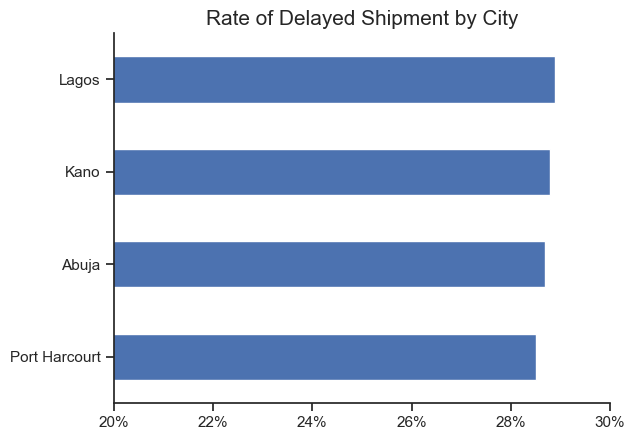

In [86]:
df_delay_count = df[df['Is_Late'] == True]
delay_count = df_delay_count['Origin_City'].value_counts().to_frame('late_shipments')
delay_count.reset_index(inplace=True)

total_count = df['Origin_City'].value_counts().to_frame('total_shipments')
total_count.reset_index(inplace=True)

df_delay_total = delay_count.merge(total_count, on='Origin_City')
df_delay_total['late_rate_%'] = ((df_delay_total['late_shipments'] / df_delay_total['total_shipments']) * 100).round(1)
df_delay_total.sort_values(by='late_rate_%', ascending=False, inplace=True)
df_delay_total[::-1].plot(kind='barh', y='late_rate_%', x='Origin_City', legend=False)

plt.title('Rate of Delayed Shipment by City', fontsize=15)
plt.ylabel('')

plt.xlim(20, 30)
ax = plt.gca()
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f'{int(x)}%'
    )
)
sns.despine()
# plt.tight_layout()

### 2.1.4 Which vehicle type has the highest delay rate?


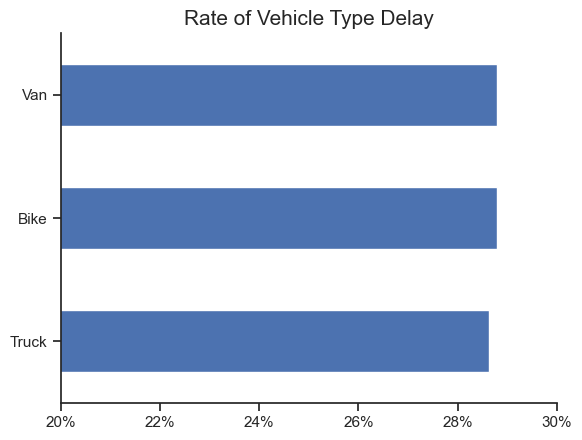

In [25]:
df_V_delay = df[df['Status'] == 'Delayed']
vehicle_delay = df_V_delay['Vehicle_Type'].value_counts().to_frame('delay_count')
vehicle_delay.reset_index(inplace=True)

vehicle_total = df['Vehicle_Type'].value_counts().to_frame('total_count')
vehicle_total.reset_index(inplace=True)

df_VD_total = vehicle_delay.merge(vehicle_total, on='Vehicle_Type')
df_VD_total['delay_rate_%'] = ((df_VD_total['delay_count'] / df_VD_total['total_count']) * 100).round(2)
df_VD_total[::-1].plot(kind='barh', y='delay_rate_%', x='Vehicle_Type', legend=False)
plt.title('Rate of Vehicle Type Delay', fontsize=15)
plt.ylabel('')
plt.xlim(20, 30)
ax = plt.gca()
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f'{int(x)}%'
    )
)
sns.despine()


### 2.1.5 Does priority level affect delay rate?


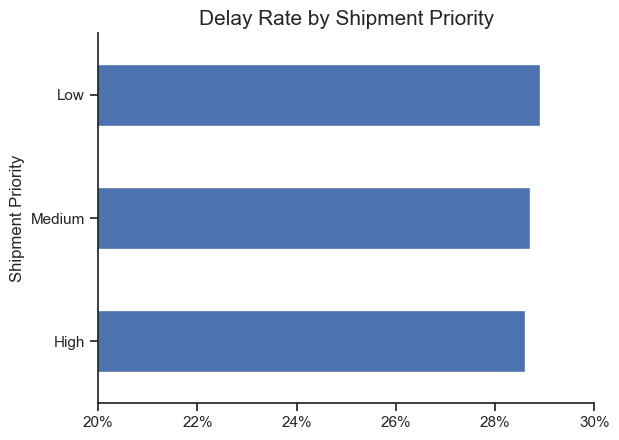

In [26]:
df_P_delay = df[df['Status'] == 'Delayed']
P_delay = df_P_delay['Priority'].value_counts().to_frame('delayed')
P_delay.reset_index(inplace=True)

P_total = df['Priority'].value_counts().to_frame('total')
P_total.reset_index(inplace=True)

df_PDT = P_delay.merge(P_total, on='Priority')
df_PDT['delay_rate_%'] = ((df_PDT['delayed'] / df_PDT['total']) * 100).round(1)
df_PDT.sort_values(by='delay_rate_%', ascending=False, inplace=True)
df_PDT[::-1].plot(kind='barh', y='delay_rate_%', x='Priority', legend=False)
plt.title('Delay Rate by Shipment Priority', fontsize=15)
plt.ylabel('Shipment Priority')
plt.xlim(20, 30)
ax = plt.gca()
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f'{int(x)}%'
    )
)
sns.despine()

### 2.1.6 Which day of the week has the most shipments? Does delay rate vary by day of the week?


In [27]:
df['Shipment_DayOfWeek'].value_counts()

Shipment_DayOfWeek
Monday       20702
Friday       20668
Tuesday      20648
Saturday     20632
Sunday       20538
Wednesday    20513
Thursday     20335
Name: count, dtype: int64

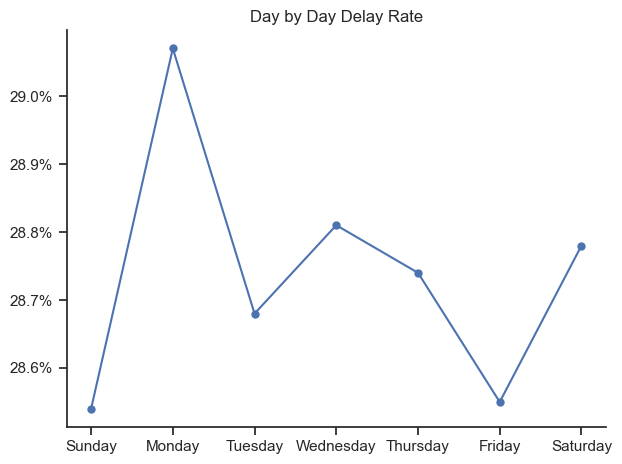

In [28]:
df_NEW = df.copy()
df_NEW['day_num'] = df_NEW['Shipment_Date'].dt.strftime('%w')
df_delay_week = df_NEW[df_NEW['Status'] == 'Delayed']


delay_D = df_delay_week[['Shipment_DayOfWeek', 'day_num']].value_counts().to_frame('delay_count')
delay_D.reset_index(inplace=True)
delay_D

total_D = df_NEW['Shipment_DayOfWeek'].value_counts().to_frame('total')
total_D.reset_index(inplace=True)

df_WDT = delay_D.merge(total_D, on='Shipment_DayOfWeek')
df_WDT.sort_values(by='day_num', inplace=True)
df_WDT.drop(columns='day_num', inplace=True)
df_WDT['delay_rate_%'] = ((df_WDT['delay_count'] / df_WDT['total']) * 100).round(2)

df_WDT.plot(kind='line', x='Shipment_DayOfWeek', y='delay_rate_%', legend=False, marker='o', ms=5)
plt.title('Day by Day Delay Rate')
ax = plt.gca()
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda y, pos: f'{(y)}%'
    )
)
plt.xlabel('')
sns.despine()
plt.tight_layout()

## 2.2 Cost & Efficiency Analysis


### 2.2.1 What is the average Cost_per_km by vehicle type? Which vehicle is most cost-efficient?


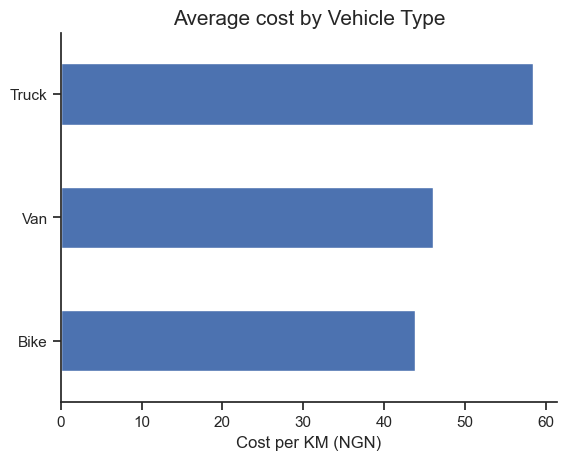

In [29]:
cost_EFF = df.groupby('Vehicle_Type')['Cost_per_km'].mean()
cost_EFF.sort_values(ascending=False, inplace=True)
cost_EFF[::-1].plot(kind='barh')
plt.title('Average cost by Vehicle Type', fontsize=15)
plt.ylabel('')
plt.xlabel('Cost per KM (NGN)')
sns.despine()

### 2.2.2 What is the average Cost_per_km by origin city? Which route is cheapest per kilometre?


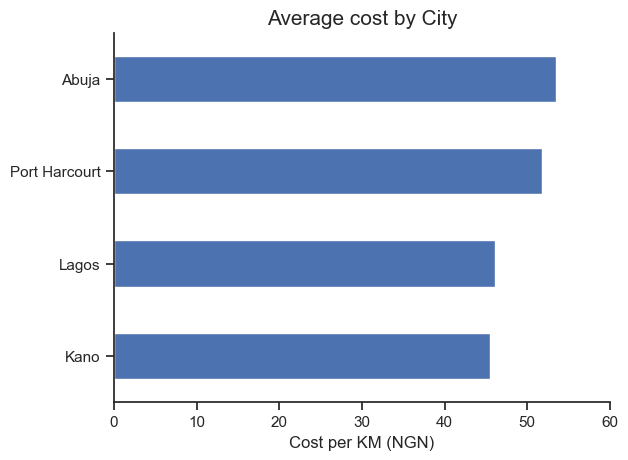

In [90]:
cost_City_KM = df.groupby('Origin_City')['Cost_per_km'].mean()
cost_City_KM.sort_values(ascending=False, inplace=True)
cost_City_KM[::-1].plot(kind='barh')

plt.title('Average cost by City', fontsize=15)
plt.ylabel('')
plt.xlabel('Cost per KM (NGN)')
plt.xlim(0, 60)
sns.despine()

`KANO has the cheapest route per KM`


### 2.2.3 Which distance band (Short/Medium/Long) has the highest average cost per shipment?


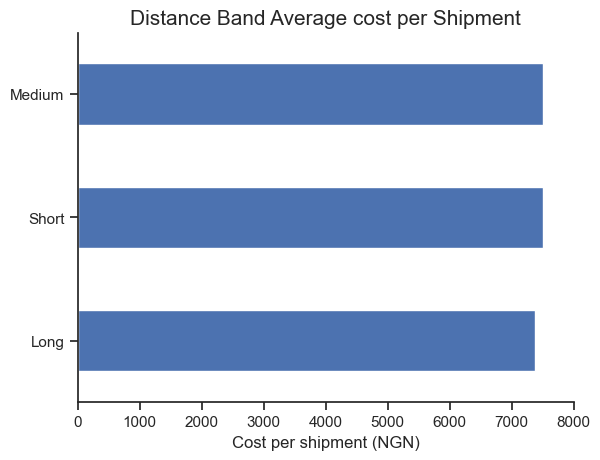

In [31]:
cost_DIST = df.groupby('Distance_Band', observed=True)['Cost_NGN'].mean()
cost_DIST.sort_values(ascending=False, inplace=True)
cost_DIST[::-1].plot(kind='barh')
plt.title('Distance Band Average cost per Shipment', fontsize=15)
plt.ylabel('')
plt.xlabel('Cost per shipment (NGN)')
plt.xlim(0, 8000)
sns.despine()

### 2.2.4 Which weight band has the highest average Cost_per_kg


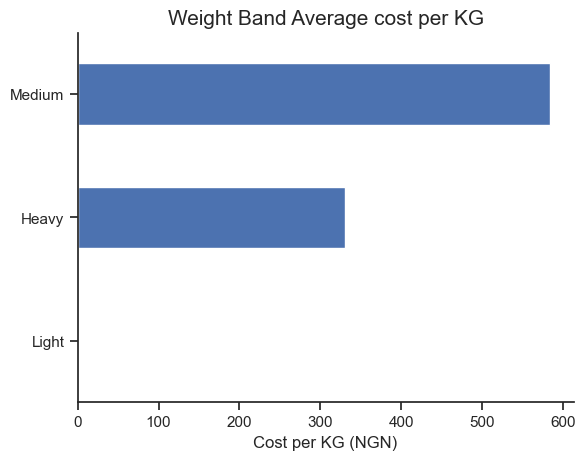

In [32]:
cost_DIST = df.groupby('Weight_Band', observed=True)['Cost_per_kg'].mean()
cost_DIST.sort_values(ascending=False, inplace=True)
cost_DIST[::-1].plot(kind='barh')
plt.title('Weight Band Average cost per KG', fontsize=15)
plt.ylabel('')
plt.xlabel('Cost per KG (NGN)')
# plt.xlim(0, 8000)
sns.despine()
# cost_DIST.isnull().sum()


## 2.3 Shipment Volume & Trends


### 2.3.1 How does total shipment volume trend month by month across all years?


In [33]:
df['Shipment_Year'] = df['Shipment_Date'].dt.year
df['Shipment_Month_no'] = df['Shipment_Date'].dt.month

df_Shipment_Vol = df.pivot_table(index='Shipment_Month_no', columns='Shipment_Year', values='Shipment_ID', aggfunc='size')

# df_Shipment_Vol.loc['Total'] = df_Shipment_Vol.sum()
# df_Shipment_Vol = df_Shipment_Vol[df_Shipment_Vol.loc['Total'].sort_values(ascending=False).index]
# df_Shipment_Vol.drop('Total', inplace=True)

# change month no to name
df_Shipment_Vol.reset_index(inplace=True)
df_Shipment_Vol['Shipment_Month'] = df_Shipment_Vol['Shipment_Month_no'].apply(lambda x:  pd.to_datetime(x, format='%m').strftime('%b'))
df_Shipment_Vol = df_Shipment_Vol.set_index('Shipment_Month')
df_Shipment_Vol.drop(columns='Shipment_Month_no', inplace=True)

df_Shipment_Vol

Shipment_Year,2022,2023,2024,2025
Shipment_Month,,,,
Jan,3125,3052,3098,3106
Feb,2671,2770,2783,2866
Mar,3061,3136,3025,3089
Apr,2963,2986,2939,2970
May,2980,2983,2975,3002
Jun,2894,2918,2979,2992
Jul,3139,3157,3063,3013
Aug,3187,3053,3085,3032
Sep,2966,2983,2970,2979


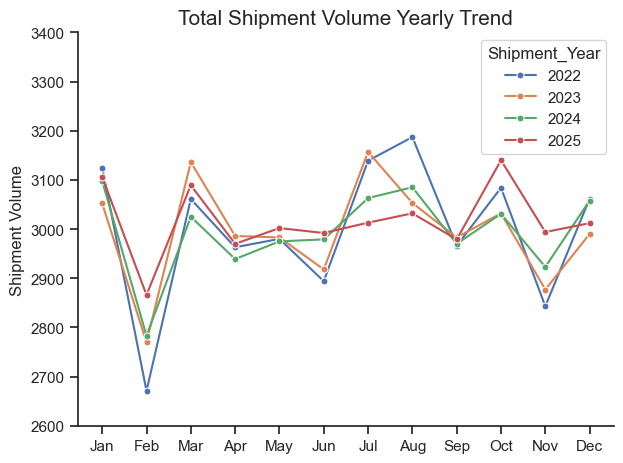

In [34]:
sns.lineplot(data=df_Shipment_Vol, dashes=False,  marker='o', ms=5)

sns.set_theme(style='ticks')
sns.despine()
plt.title('Total Shipment Volume Yearly Trend', fontsize=15)
plt.xlabel('')
plt.ylabel('Shipment Volume')
plt.ylim(2600, 3400)

plt.tight_layout()

### 2.3.2 Which quarter consistently has the highest shipment volume?


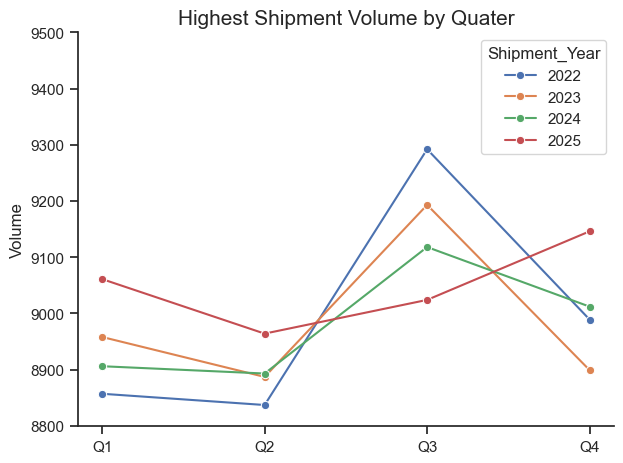

In [35]:
df_Quater_Vol = df.pivot_table(index='Shipment_Quater', columns='Shipment_Year', values='Shipment_ID', aggfunc='size')

sns.lineplot(data=df_Quater_Vol, dashes=False,  marker='o')
sns.set_theme(style='ticks')
plt.title('Highest Shipment Volume by Quater', fontsize=15)
plt.xlabel('')
plt.ylabel('Volume')

plt.ylim(8800, 9500)
sns.despine()
plt.tight_layout()

`Q3 has the highest shipment volume`


### 2.3.3 Which origin city ships the most volume overall?


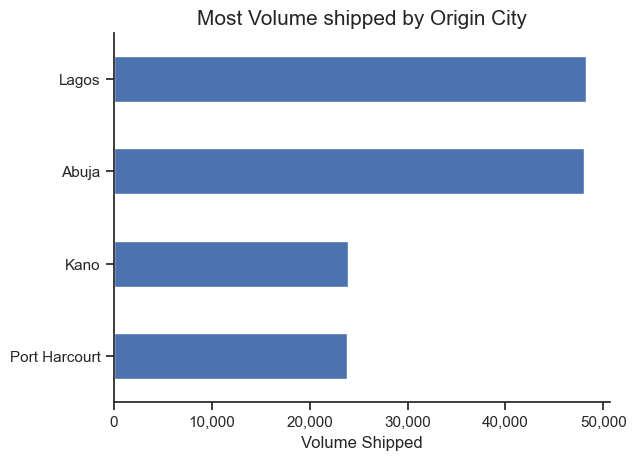

In [36]:
df['Origin_City'].value_counts()[::-1].plot(kind='barh')
plt.title('Most Volume shipped by Origin City', fontsize=15)
plt.xlabel('Volume Shipped')
plt.ylabel('')
sns.despine()
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x):,}'))

`LAGOS, closely followed by ABUJA ships the most volume overall`


### 2.3.4 What is the most common vehicle type used? and does it vary by origin city?


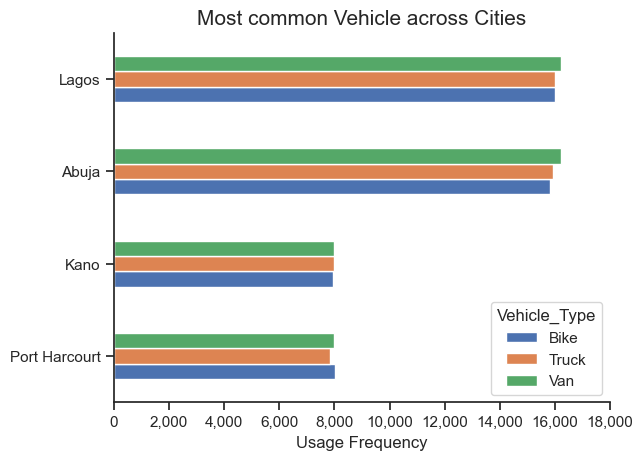

In [37]:
df_V_City = df.pivot_table(index='Origin_City', columns='Vehicle_Type', aggfunc='size')

# Sorting the columns
df_V_City['Total'] = df_V_City.sum(axis=1)
df_V_City.sort_values(by='Total', ascending=False, inplace=True)
df_V_City.drop(columns='Total', inplace=True)
# df_V_City.sort_values(by='Bike', ascending=False, inplace=True)

df_V_City[::-1].plot(kind='barh')
plt.title('Most common Vehicle across Cities', fontsize=15)
plt.xlim(0, 18000)
plt.ylabel('')
plt.xlabel('Usage Frequency')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x):,}'))
sns.despine()

`The most common vehicle type used is VAN`


## 2.4 Insurance & Payment


### 2.4.1 What percentage of shipments have insurance?


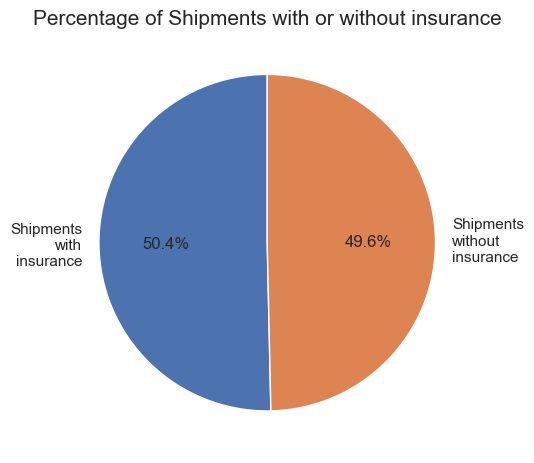

In [38]:
df_Insure = df['Insurance'].value_counts()
# df_Insure.plot(kind='pie', startangle=90, autopct='%1.1f%%')
plt.pie(df_Insure, startangle=90, autopct='%1.1f%%', labels=['Shipments\nwith\ninsurance', 'Shipments\nwithout\ninsurance'])
plt.title('Percentage of Shipments with or without insurance', fontsize=15)
plt.ylabel('')
plt.tight_layout()

### 2.4.2 Does having insurance correlate with higher shipment cost? do insured shipments cost more on average?


(4500.0, 8000.0)

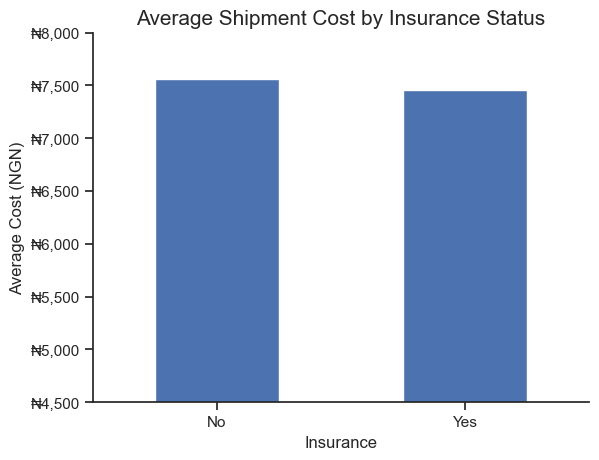

In [39]:
df_Insure_COST = df.groupby('Insurance')['Cost_NGN'].mean().round(2)

df_Insure_COST.plot(kind='bar', legend=False)
plt.title('Average Shipment Cost by Insurance Status', fontsize=15)
plt.ylabel('Average Cost (NGN)')
plt.xticks(rotation=0)
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'₦{int(y):,}'))
sns.despine()
plt.ylim(4500, 8000)
# plt.tight_layout()

`Insured shipments are actually slightly cheaper on average (₦7,458 vs ₦7,556)`


### 2.4.3 What is the most common payment method? and does it vary by priority level?


Payment_Method
Cash        48184
Transfer    48122
Card        47730
Name: count, dtype: int64

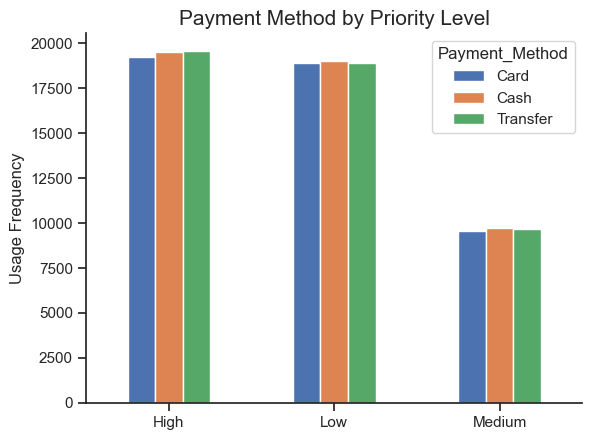

In [40]:
plot_PAYMENT_prority = df.pivot_table(index='Priority', columns='Payment_Method', aggfunc='size')
plot_PAYMENT_prority.plot(kind='bar')
plt.title('Payment Method by Priority Level', fontsize=15)
plt.xlabel('')
plt.ylabel('Usage Frequency')
plt.xticks(rotation=0)
sns.despine()

df['Payment_Method'].value_counts()

`The most common payment method is Cash and it varies slightly by Priority level`
